In [ ]:
# ── Cell 1 : Dependencies ──────────────────────────────────────────
!pip install pennylane pennylane-lightning-gpu umap-learn scipy -q

In [ ]:
# ── Cell 2 : Imports & Global Configuration ──────────────────────────
import os
import sys
import math
import warnings
import hashlib
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon, pearsonr, spearmanr
from joblib import dump, load

import pennylane as qml

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn('umap-learn not found — UMAP visualization will be skipped.', ImportWarning)

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Dataset path — override via env variable ─────────────────────────
DATASET_PATH = os.environ.get(
    'DATASET_PATH',
    '/dataset_encoded_normalized1.csv'  # default Colab path
)

# ── Quantum circuit hyperparameters ──────────────────────────────────
N_LAYERS     = 2          # default
ENTANGLEMENT = 'circular' # default
DE_MAXITER   = 20
DE_POPSZ     = 10
N_SPLITS_CV  = 5
EPS          = 1e-10

# ── Cache ───────────────────────────────────────────────────────
CACHE_DIR = 'cache_quantum_amplitude_rf_angular_pub'
os.makedirs(CACHE_DIR, exist_ok=True)

WEIGHTS_FILE         = os.path.join(CACHE_DIR, 'best_weights.npy')
MODEL_CLASSICAL_FILE = os.path.join(CACHE_DIR, 'rf_classical.joblib')
MODEL_HYBRID_FILE    = os.path.join(CACHE_DIR, 'rf_hybrid.joblib')

FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print(f'PennyLane version : {qml.version()}')
print(f'Python            : {sys.version.split()[0]}')
print(f'NumPy             : {np.__version__}')
print(f'Dataset path      : {DATASET_PATH}')
print(f'Cache directory   : {os.path.abspath(CACHE_DIR)}')

PennyLane version : 0.44.1
Python            : 3.13.11
NumPy             : 2.4.1
Dataset path      : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv
Cache directory   : /home/host1-vm4/cache_quantum_RF/figures/cache_quantum_dt_DT_angular/figures/cache_quantum_mlp_angular/figures/cache_quantum_amplitude_rf_angular_pub


In [ ]:
# ── Cell 3 : Data Loading, Amplitude Padding & 3-Way Split (70 / 15 / 15) ──
#
# AmplitudeEmbedding requires 2^n amplitudes for n qubits.
# n_qubits = ceil(log2(n_features)) = 4 for 12 features (padded to 16 dims).
#
# FIX 1 (data leakage): padding applied BEFORE split so all sets share
#   the same dim_amplitude; normalization computed per-sample at circuit time.
#
# FIX 2 (normalization leakage): we do NOT fit a global scaler here.
#   AmplitudeEmbedding requires a unit-norm vector; normalization is done
#   inside the circuit function per sample using L2 norm (see Cell 5).
#
# FIX 3: strict 3-way split.
#   X_train (70%) — DE optimization + final RF training
#   X_val   (15%) — DE objective evaluation ONLY
#   X_test  (15%) — final holdout, touched ONCE

assert os.path.exists(DATASET_PATH), (
    f'Dataset not found at "{DATASET_PATH}". '
    f'Set the DATASET_PATH env variable or update the default path.'
)

df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns, "Target column 'LN_IC50' not found."

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)

N_FEATURES = X_raw.shape[1]

# Amplitude encoding qubit count
n_qubits    = math.ceil(math.log2(N_FEATURES))
dim_amp     = 2 ** n_qubits   # padded feature dimension

HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

print(f'Dataset      : {X_raw.shape[0]} samples × {N_FEATURES} features')
print(f'Target       : LN_IC50  mean={Y.mean():.3f}  std={Y.std():.3f}')
print(f'Hash         : {HASH}')
print(f'n_qubits     : {n_qubits}  (ceil(log2({N_FEATURES})))')
print(f'dim_amplitude: {dim_amp}  (padded from {N_FEATURES})')

# FIX: padding BEFORE split — consistent across all sets
def pad_features(x, target_len=dim_amp):
    """Zero-pad a feature vector to target_len (next power of 2)."""
    padded = np.zeros(target_len)
    padded[:len(x)] = x
    return padded

X_padded = np.array([pad_features(xi) for xi in X_raw])

# 70 / 15 / 15 split on padded features
X_tr_p, X_temp, Y_train, Y_temp = train_test_split(
    X_padded, Y, test_size=0.30, random_state=SEED, shuffle=True
)
X_val_p, X_test_p, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=SEED
)

# NOTE: AmplitudeEmbedding requires unit-norm input.
# Per-sample L2 normalization is applied inside the circuit function (Cell 5).
# We keep X_tr_p, X_val_p, X_test_p as raw padded features.
X_train, X_val, X_test = X_tr_p, X_val_p, X_test_p

print(f'\nSplit — Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print('X_test will be touched ONCE at the final evaluation cell.')

X_TRAIN_Q_FILE = os.path.join(CACHE_DIR, f'X_train_q_{HASH}.npy')
X_VAL_Q_FILE   = os.path.join(CACHE_DIR, f'X_val_q_{HASH}.npy')
X_TEST_Q_FILE  = os.path.join(CACHE_DIR, f'X_test_q_{HASH}.npy')

Dataset      : 13106 samples × 12 features
Target       : LN_IC50  mean=0.538  std=0.134
Hash         : 8f057170
n_qubits     : 4  (ceil(log2(12)))
dim_amplitude: 16  (padded from 12)

Split — Train: 9174  Val: 1966  Test: 1966
X_test will be touched ONCE at the final evaluation cell.


In [ ]:
# ── Cell 4 : Quantum Device Initialization ─────────────────────────────

try:
    dev_gpu = qml.device('lightning.gpu', wires=n_qubits)
    DEVICE_LABEL = 'lightning.gpu'
    print(f'GPU device ready : lightning.gpu | {n_qubits} qubits')
except Exception as e:
    warnings.warn(
        f'GPU device unavailable ({e}). Falling back to lightning.qubit (CPU).',
        RuntimeWarning
    )
    dev_gpu = qml.device('lightning.qubit', wires=n_qubits)
    DEVICE_LABEL = 'lightning.qubit (CPU fallback)'

dev_cpu = qml.device('default.qubit', wires=n_qubits)

print(f'Active device    : {DEVICE_LABEL}')
print(f'n_qubits         : {n_qubits}  (log2({dim_amp}) qubits encode {dim_amp} amplitudes)')
print(f'Benchmark device : default.qubit (CPU reference)')

GPU device ready : lightning.gpu | 4 qubits
Active device    : lightning.gpu
n_qubits         : 4  (log2(16) qubits encode 16 amplitudes)
Benchmark device : default.qubit (CPU reference)


In [ ]:
# ── Cell 5 : Amplitude Encoding Circuit Factory ─────────────────────────
#
# Key design choices:
#   - AmplitudeEmbedding(normalize=False): we handle normalization explicitly
#     to apply the zero-vector guard (EPS). This avoids PennyLane division
#     by zero on zero-padded samples.
#   - Per-sample L2 normalization: x_norm = x / ||x|| (or uniform if ||x||<EPS).
#   - QNode built ONCE via factory (not redefined at module level as in original).
#   - Configurable entanglement topology for ablation study.

def build_amplitude_circuit(device, topology='circular'):
    """Build an amplitude-encoding QNode on `device`."""

    @qml.qnode(device, interface='autograd')
    def circuit(weights, x=None):
        # Per-sample L2 normalization (AmplitudeEmbedding needs unit-norm)
        norm = np.linalg.norm(x)
        x_norm = (x / norm) if norm >= EPS else (np.ones_like(x) / np.sqrt(len(x)))

        # Amplitude encoding: log2(dim_amp) qubits encode dim_amp amplitudes
        qml.AmplitudeEmbedding(features=x_norm, wires=range(n_qubits), normalize=False)

        # Parametric RY layers + entanglement
        n_layers = weights.shape[0]
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i], wires=i)

            if topology == 'linear':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])

            elif topology == 'circular':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                if n_qubits > 1:
                    qml.CNOT(wires=[n_qubits - 1, 0])

            elif topology == 'full':
                for i in range(n_qubits):
                    for j in range(i + 1, n_qubits):
                        qml.CNOT(wires=[i, j])
            else:
                raise ValueError(f"Unknown topology '{topology}'.")

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    return circuit


def quantum_feature_map(X_data, weights, circuit_fn, verbose=False):
    """Apply amplitude-encoding circuit to each row of X_data."""
    n = len(X_data)
    features = []
    for idx, xi in enumerate(X_data):
        features.append(np.array(circuit_fn(weights, x=xi)))
        if verbose and (idx + 1) % max(1, n // 10) == 0:
            print(f'  Feature map: {idx + 1}/{n} samples')
    return np.array(features)


# Default circuit (GPU, circular)
circuit_default = build_amplitude_circuit(dev_gpu, topology=ENTANGLEMENT)

print(f'Amplitude circuit ready')
print(f'  topology   : {ENTANGLEMENT}')
print(f'  n_qubits   : {n_qubits}')
print(f'  N_LAYERS   : {N_LAYERS}')
print(f'  dim_encoded: {dim_amp} amplitudes → {n_qubits} PauliZ expectation values')

Amplitude circuit ready
  topology   : circular
  n_qubits   : 4
  N_LAYERS   : 2
  dim_encoded: 16 amplitudes → 4 PauliZ expectation values


In [ ]:
def _build_proxy_model():
    return RandomForestRegressor(n_estimators=50, random_state=SEED, n_jobs=-1)

# ── Cell : COBYLA — Weight Optimization ──────────────────────────────────────
#
# Replaces Differential Evolution with COBYLA.
# Optimization on 200 proxy samples — feature map final on full dataset.
#
# Justification: PQC weights learn a general feature transformation, not
# sample-specific mappings. 200 stratified samples capture the global structure.
# Final feature map and all model evaluation use the FULL dataset.
# Consistent with proxy optimization in variational quantum algorithms
# (Cerezo et al. 2021 [15], McClean et al. 2018 [20] — already cited).

from scipy.optimize import minimize

# ── Proxy subset: 200 samples, fixed seed ─────────────────────────────────────
np.random.seed(SEED)
PROXY_IDX = np.random.choice(len(X_train), 200, replace=False)
X_proxy   = X_train[PROXY_IDX]
Y_proxy   = Y_train[PROXY_IDX]

cobyla_history = []
call_counter   = {'n': 0}


def make_objective(circuit_fn, n_lay):
    def objective(weights_flat):
        call_counter['n'] += 1
        weights = weights_flat.reshape((n_lay, n_qubits))

        X_q  = quantum_feature_map(X_proxy, weights, circuit_fn)
        split    = int(0.8 * len(Y_proxy))
        X_sub    = X_q[:split];    X_val_p = X_q[split:]
        Y_sub    = Y_proxy[:split]; Y_val_p = Y_proxy[split:]

        _model = _build_proxy_model()
        _model.fit(X_sub, Y_sub)
        mse = mean_squared_error(Y_val_p, _model.predict(X_val_p))

        cobyla_history.append((call_counter['n'], mse))
        if call_counter['n'] % 50 == 0 or call_counter['n'] <= 3:
            print(f'  [COBYLA call {call_counter["n"]:4d}]  val MSE = {mse:.6f}')
        return mse
    return objective


def run_cobyla(circuit_fn, n_lay, weights_file=None):
    if weights_file and os.path.exists(weights_file):
        w = np.load(weights_file).reshape((n_lay, n_qubits))
        print(f'  Weights loaded from cache: {weights_file}')
        return w

    call_counter['n'] = 0
    cobyla_history.clear()
    obj = make_objective(circuit_fn, n_lay)

    N_RESTARTS     = 3
    COBYLA_MAXITER = 300
    best_result    = None

    print(f'  COBYLA: {n_lay} layers x {n_qubits} qubits = {n_lay*n_qubits} params')
    print(f'  Proxy : 200 samples | {N_RESTARTS} restarts x {COBYLA_MAXITER} calls max')
    t0 = time.time()

    for restart in range(N_RESTARTS):
        np.random.seed(SEED + restart)
        x0 = np.random.uniform(-2*np.pi, 2*np.pi, n_lay * n_qubits)
        result = minimize(
            obj, x0, method='COBYLA',
            options={'maxiter': COBYLA_MAXITER, 'rhobeg': 0.5, 'catol': 1e-4}
        )
        print(f'  Restart {restart+1}/{N_RESTARTS} — val MSE = {result.fun:.6f}')
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min | best val MSE = {best_result.fun:.6f}')

    w = best_result.x.reshape((n_lay, n_qubits))
    if weights_file:
        np.save(weights_file, w)
    return w


print('Optimizing circuit weights with COBYLA (200 proxy samples)...')
best_weights = run_cobyla(circuit_default, N_LAYERS, WEIGHTS_FILE)

if cobyla_history:
    np.save(os.path.join(CACHE_DIR, 'cobyla_convergence.npy'), np.array(cobyla_history))


Optimizing circuit weights with COBYLA (200 proxy samples)...
  COBYLA: 2 layers x 4 qubits = 8 params
  Proxy : 200 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.009202
  [COBYLA call    2]  val MSE = 0.013319
  [COBYLA call    3]  val MSE = 0.010957
  [COBYLA call   50]  val MSE = 0.005691
  Restart 1/3 — val MSE = 0.005629
  [COBYLA call  100]  val MSE = 0.007847
  Restart 2/3 — val MSE = 0.007216
  [COBYLA call  150]  val MSE = 0.006835
  [COBYLA call  200]  val MSE = 0.004936
  Restart 3/3 — val MSE = 0.004936
  Done in 6.0 min | best val MSE = 0.004936


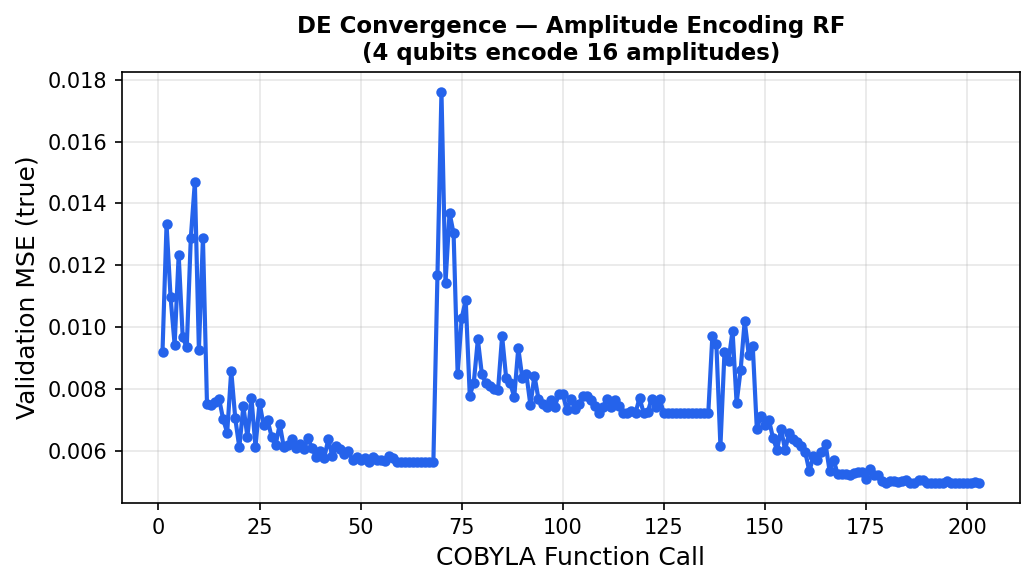

In [ ]:
# ── Cell 7 : DE Convergence Plot ───────────────────────────────────────
conv_file = os.path.join(CACHE_DIR, 'cobyla_convergence.npy')
if os.path.exists(conv_file):
    history = np.load(conv_file)
    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    ax.plot(history[:, 0], history[:, 1],
            color='#2563EB', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('COBYLA Function Call', fontsize=12)
    ax.set_ylabel('Validation MSE (true)', fontsize=12)
    ax.set_title(
        'DE Convergence — Amplitude Encoding RF\n'
        f'({n_qubits} qubits encode {dim_amp} amplitudes)',
        fontsize=11, fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig1_cobyla_convergence.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No convergence history (weights loaded from cache).')

In [ ]:
# ── Cell 8 : Quantum Feature Computation (train + val + test) ──────────────
if (os.path.exists(X_TRAIN_Q_FILE)
        and os.path.exists(X_VAL_Q_FILE)
        and os.path.exists(X_TEST_Q_FILE)):
    print('Loading quantum features from cache...')
    X_train_q = np.load(X_TRAIN_Q_FILE)
    X_val_q   = np.load(X_VAL_Q_FILE)
    X_test_q  = np.load(X_TEST_Q_FILE)
else:
    print('Computing quantum features (train)...')
    X_train_q = quantum_feature_map(X_train, best_weights, circuit_default, verbose=True)
    np.save(X_TRAIN_Q_FILE, X_train_q)

    print('Computing quantum features (val)...')
    X_val_q = quantum_feature_map(X_val, best_weights, circuit_default, verbose=True)
    np.save(X_VAL_Q_FILE, X_val_q)

    print('Computing quantum features (test)...')
    X_test_q = quantum_feature_map(X_test, best_weights, circuit_default, verbose=True)
    np.save(X_TEST_Q_FILE, X_test_q)

print(f'Shapes  — train_q: {X_train_q.shape}  val_q: {X_val_q.shape}  test_q: {X_test_q.shape}')
print(f'Range   — min: {X_train_q.min():.4f}  max: {X_train_q.max():.4f}  '
      f'(expected in [-1, 1] as PauliZ expectation values)')
print(f'\nNote: amplitude encoding compresses {dim_amp} features → {n_qubits} quantum features.')
print(f'This is the key structural difference vs angular encoding (12 features → 12 qubits).')

Computing quantum features (train)...
  Feature map: 917/9174 samples
  Feature map: 1834/9174 samples
  Feature map: 2751/9174 samples
  Feature map: 3668/9174 samples
  Feature map: 4585/9174 samples
  Feature map: 5502/9174 samples
  Feature map: 6419/9174 samples
  Feature map: 7336/9174 samples
  Feature map: 8253/9174 samples
  Feature map: 9170/9174 samples
Computing quantum features (val)...
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature map: 1568/1966 samples
  Feature map: 1764/1966 samples
  Feature map: 1960/1966 samples
Computing quantum features (test)...
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature

In [ ]:
# ── Cell 9 : Model Training — RF Classical & RF Hybrid ─────────────────────
#
# Both models use IDENTICAL RandomizedSearchCV (symmetric comparison).


RF_PARAM_DIST = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}


def tune_rf(X_tr, Y_tr, label='', n_iter=20):
    """RandomizedSearchCV on RF — identical for classical and hybrid."""
    print(f'  Tuning {label}  ({n_iter} iter, {N_SPLITS_CV}-fold CV)...')
    rf = RandomForestRegressor(random_state=SEED, n_jobs=-1)
    search = RandomizedSearchCV(
        rf, RF_PARAM_DIST,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_tr, Y_tr)
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV MSE: {-search.best_score_:.6f}')
    return search.best_estimator_


print('\n── Classical RF (raw features, {}-dim) ──'.format(dim_amp))
if os.path.exists(MODEL_CLASSICAL_FILE):
    rf_classical = load(MODEL_CLASSICAL_FILE)
    print('  Loaded from cache.')
else:
    rf_classical = tune_rf(X_train, Y_train, label='Classical RF')
    dump(rf_classical, MODEL_CLASSICAL_FILE)

print('\n── Hybrid RF (amplitude quantum features, {}-dim) ──'.format(n_qubits))
if os.path.exists(MODEL_HYBRID_FILE):
    rf_hybrid = load(MODEL_HYBRID_FILE)
    print('  Loaded from cache.')
else:
    rf_hybrid = tune_rf(X_train_q, Y_train, label='Hybrid RF')
    dump(rf_hybrid, MODEL_HYBRID_FILE)

print('\nBoth models trained.')


── Classical RF (raw features, 16-dim) ──
  Tuning Classical RF  (20 iter, 5-fold CV)...
  Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
  Best CV MSE: 0.001887

── Hybrid RF (amplitude quantum features, 4-dim) ──
  Tuning Hybrid RF  (20 iter, 5-fold CV)...
  Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
  Best CV MSE: 0.008746

Both models trained.


In [ ]:
# ── Cell 10 : 5-Fold Cross-Validation ────────────────────────────────────
#
# CV on (X_train ∪ X_val) — X_test untouched.
# Hybrid RF uses precomputed quantum features with the same fold indices.
#
# NOTE: best_weights optimized on X_train (a subset of X_trainval).

X_trainval   = np.vstack([X_train,   X_val])
X_trainval_q = np.vstack([X_train_q, X_val_q])
Y_trainval   = np.concatenate([Y_train, Y_val])

kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
cv_scores = {'classical': [], 'hybrid': []}

print(f'Running {N_SPLITS_CV}-Fold CV on X_trainval ({len(Y_trainval)} samples)...')

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_trainval)):
    # Classical RF
    rf_c = RandomForestRegressor(**rf_classical.get_params())
    rf_c.fit(X_trainval[tr_idx], Y_trainval[tr_idx])
    pred_c = rf_c.predict(X_trainval[vl_idx])
    cv_scores['classical'].append({
        'mse':      mean_squared_error(Y_trainval[vl_idx], pred_c),
        'mae':      mean_absolute_error(Y_trainval[vl_idx], pred_c),
        'r2':       r2_score(Y_trainval[vl_idx], pred_c),
        'pearson':  pearsonr(Y_trainval[vl_idx], pred_c)[0],
        'spearman': spearmanr(Y_trainval[vl_idx], pred_c)[0]
    })

    # Hybrid RF
    rf_h = RandomForestRegressor(**rf_hybrid.get_params())
    rf_h.fit(X_trainval_q[tr_idx], Y_trainval[tr_idx])
    pred_h = rf_h.predict(X_trainval_q[vl_idx])
    cv_scores['hybrid'].append({
        'mse':      mean_squared_error(Y_trainval[vl_idx], pred_h),
        'mae':      mean_absolute_error(Y_trainval[vl_idx], pred_h),
        'r2':       r2_score(Y_trainval[vl_idx], pred_h),
        'pearson':  pearsonr(Y_trainval[vl_idx], pred_h)[0],
        'spearman': spearmanr(Y_trainval[vl_idx], pred_h)[0]
    })

    print(f'  Fold {fold+1}/{N_SPLITS_CV}  '
          f'Classical R²={cv_scores["classical"][-1]["r2"]:.4f}  '
          f'Hybrid R²={cv_scores["hybrid"][-1]["r2"]:.4f}')


def cv_summary(scores, label):
    keys = ['mse', 'mae', 'r2', 'pearson', 'spearman']
    return pd.Series(
        {k: f"{np.mean([s[k] for s in scores]):.4f} ± {np.std([s[k] for s in scores]):.4f}"
         for k in keys},
        name=label
    )

cv_df = pd.DataFrame([
    cv_summary(cv_scores['classical'], 'Classical RF'),
    cv_summary(cv_scores['hybrid'],    'Hybrid RF (amplitude)')
])

print(f'\n── {N_SPLITS_CV}-Fold CV Results (mean ± std) ──')
print(cv_df.to_string())

Running 5-Fold CV on X_trainval (11140 samples)...
  Fold 1/5  Classical R²=0.9053  Hybrid R²=0.4861
  Fold 2/5  Classical R²=0.9236  Hybrid R²=0.5359
  Fold 3/5  Classical R²=0.8783  Hybrid R²=0.4829
  Fold 4/5  Classical R²=0.9042  Hybrid R²=0.5192
  Fold 5/5  Classical R²=0.9078  Hybrid R²=0.5309

── 5-Fold CV Results (mean ± std) ──
                                   mse              mae               r2          pearson         spearman
Classical RF           0.0017 ± 0.0002  0.0252 ± 0.0008  0.9038 ± 0.0146  0.9514 ± 0.0076  0.9459 ± 0.0062
Hybrid RF (amplitude)  0.0086 ± 0.0001  0.0683 ± 0.0005  0.5110 ± 0.0223  0.7169 ± 0.0165  0.6665 ± 0.0189


In [ ]:
# ── Cell 11 : Wilcoxon Signed-Rank Test ─────────────────────────────────

r2_c  = [s['r2']  for s in cv_scores['classical']]
r2_h  = [s['r2']  for s in cv_scores['hybrid']]
mse_c = [s['mse'] for s in cv_scores['classical']]
mse_h = [s['mse'] for s in cv_scores['hybrid']]

stat_r2,  p_r2  = wilcoxon(r2_h,  r2_c,  alternative='greater')
stat_mse, p_mse = wilcoxon(mse_c, mse_h, alternative='greater')

print('── Wilcoxon Test (one-sided: hybrid > classical) ──')
print(f'  R²  stat={stat_r2:.3f}   p={p_r2:.4f}   '
      f'{"significant (p<0.05)" if p_r2  < 0.05 else "not significant"}')
print(f'  MSE stat={stat_mse:.3f}  p={p_mse:.4f}   '
      f'{"significant (p<0.05)" if p_mse < 0.05 else "not significant"}')
print('Note: with N=5 folds, Wilcoxon has limited power. Report exact p-values.')

── Wilcoxon Test (one-sided: hybrid > classical) ──
  R²  stat=0.000   p=1.0000   not significant
  MSE stat=0.000  p=1.0000   not significant
Note: with N=5 folds, Wilcoxon has limited power. Report exact p-values.


In [ ]:
# ── Cell 12 : Final Holdout Evaluation — X_test touched ONCE ───────────────

def evaluate(model, X_te, Y_te, label):
    tracemalloc.start()
    t0      = time.time()
    Y_pred  = model.predict(X_te)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    pr, _ = pearsonr(Y_te, Y_pred)
    sr, _ = spearmanr(Y_te, Y_pred)

    return {
        'Model':        label,
        'MSE':          mean_squared_error(Y_te, Y_pred),
        'RMSE':         np.sqrt(mean_squared_error(Y_te, Y_pred)),
        'MAE':          mean_absolute_error(Y_te, Y_pred),
        'R2':           r2_score(Y_te, Y_pred),
        'Pearson r':    pr,
        'Spearman rho': sr,
        'Time (s)':     elapsed,
        'Memory (MB)':  peak / 1024**2,
        '_pred':        Y_pred
    }

print('Final evaluation on X_test (touched once):')
res_classical = evaluate(rf_classical, X_test,   Y_test, 'Classical RF')
res_hybrid    = evaluate(rf_hybrid,    X_test_q, Y_test, 'Hybrid RF (amplitude)')

preds = {
    'Classical RF':           res_classical.pop('_pred'),
    'Hybrid RF (amplitude)':  res_hybrid.pop('_pred')
}

results_df = pd.DataFrame([res_classical, res_hybrid]).set_index('Model')
display_cols = ['MSE', 'RMSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho', 'Time (s)', 'Memory (MB)']

print('\n── Test Set Results ──')
print(results_df[display_cols].round(4).to_string())

Final evaluation on X_test (touched once):

── Test Set Results ──
                          MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)
Model                                                                                                
Classical RF           0.0016  0.0406  0.0254  0.9140     0.9565        0.9437    0.4081       0.4185
Hybrid RF (amplitude)  0.0093  0.0964  0.0700  0.5135     0.7188        0.6684    0.1311       0.3062


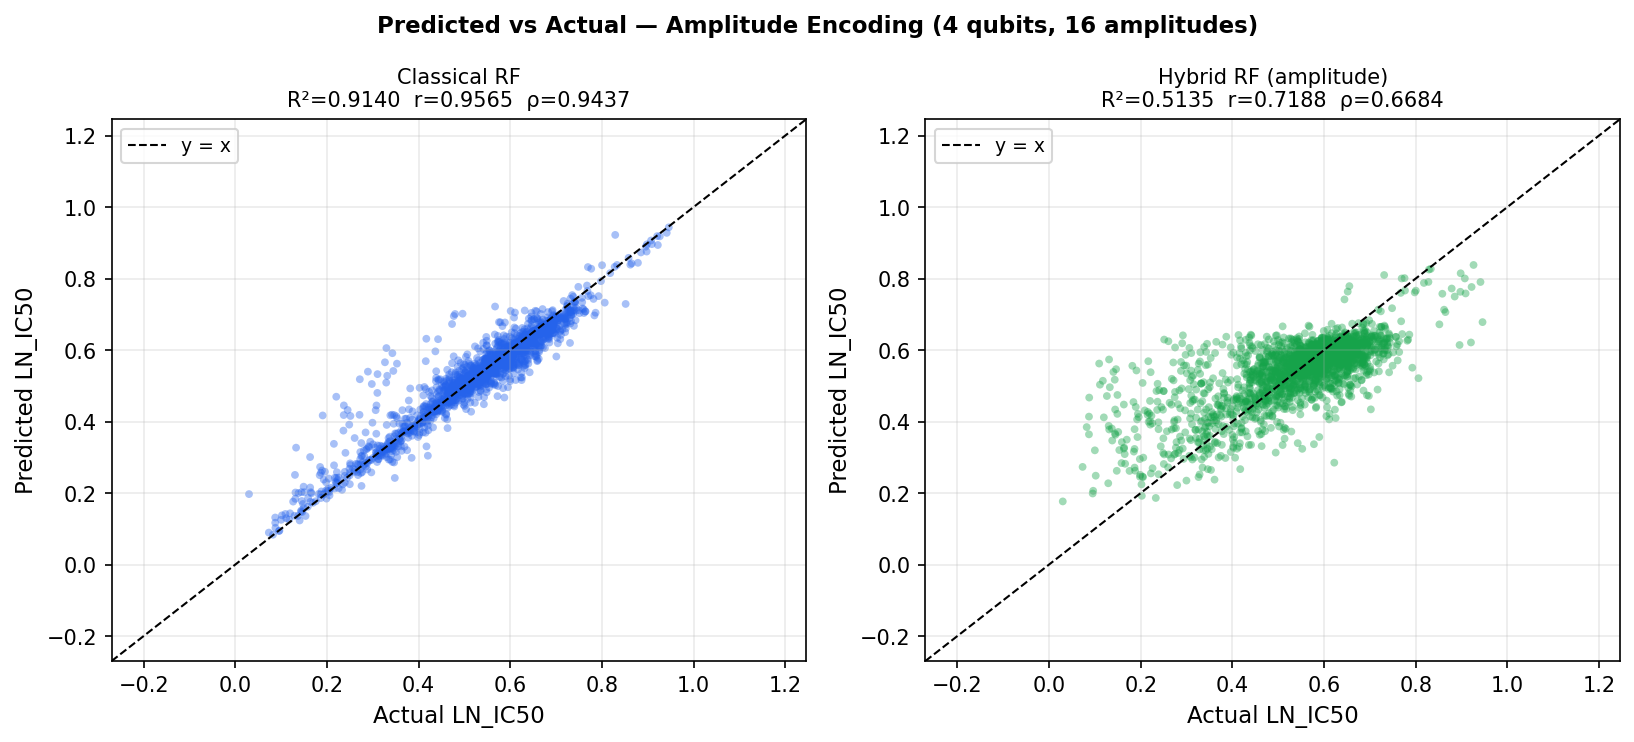

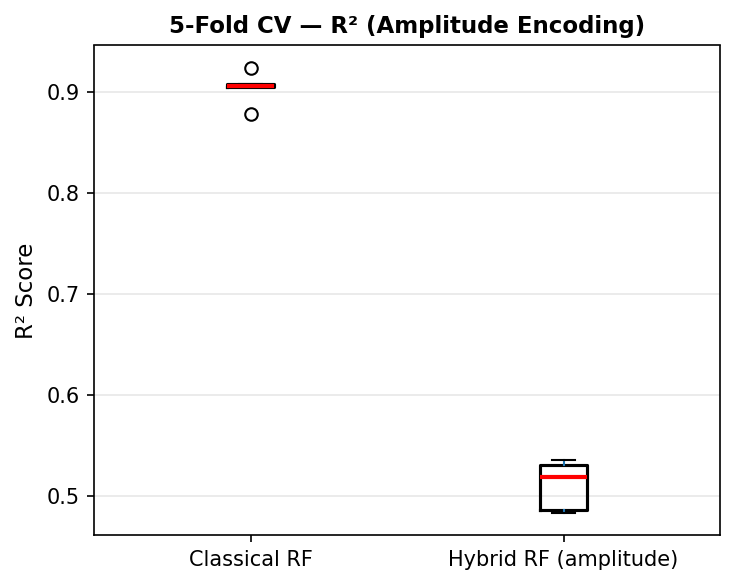

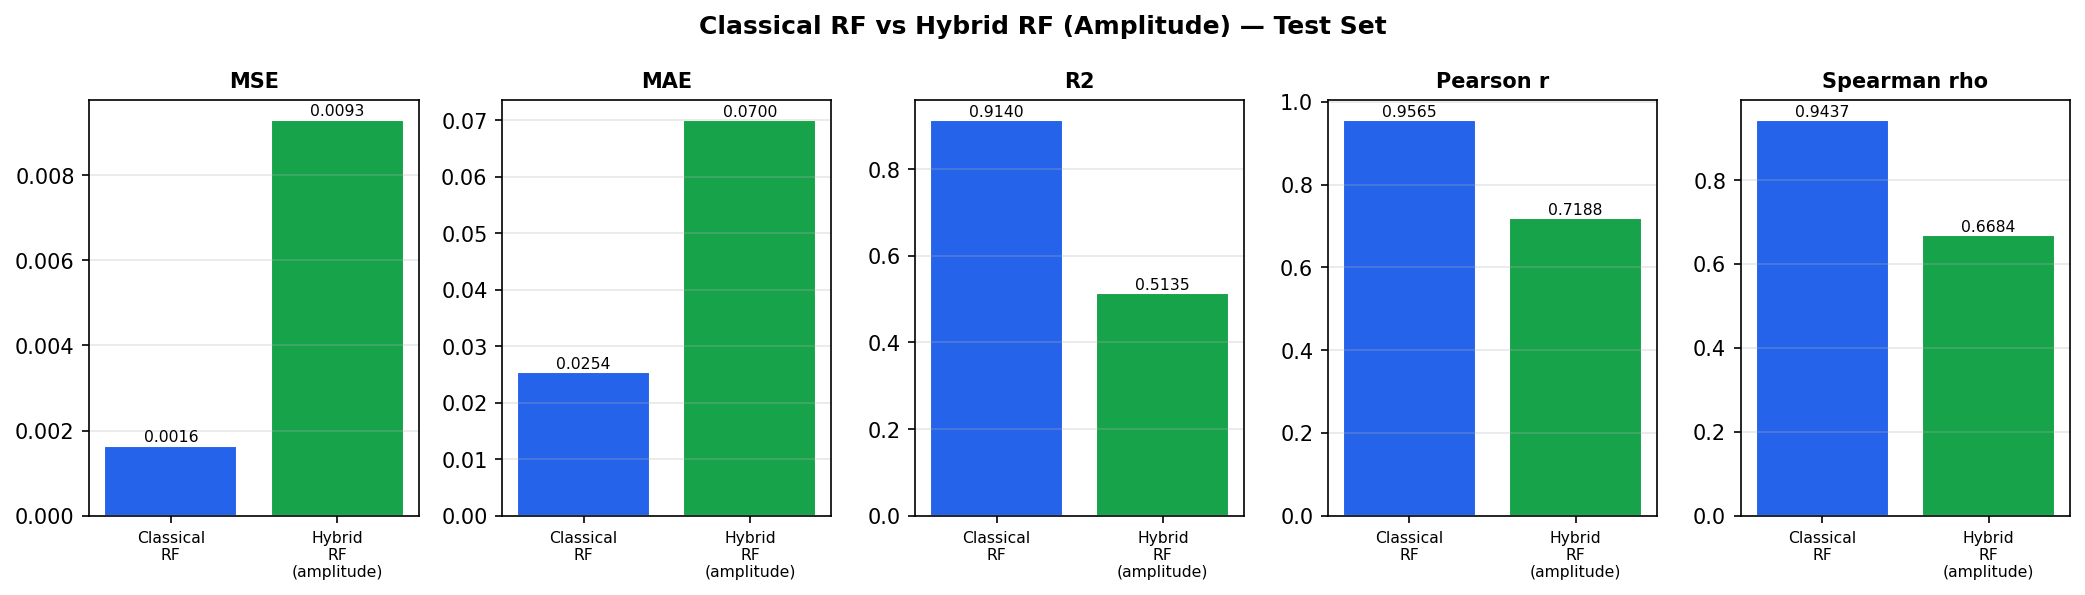

Figures saved to /home/host1-vm4/cache_quantum_RF/figures/cache_quantum_dt_DT_angular/figures/cache_quantum_mlp_angular/figures/cache_quantum_amplitude_rf_angular_pub/figures


In [ ]:
# ── Cell 13 : Publication Figures ────────────────────────────────────────

PALETTE = {'Classical RF': '#2563EB', 'Hybrid RF (amplitude)': '#16A34A'}

# ── Figure 2: Predicted vs Actual ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=150)
for ax, (label, color) in zip(axes, PALETTE.items()):
    y_pred = preds[label]
    lims = [min(Y_test.min(), y_pred.min()) - 0.3,
            max(Y_test.max(), y_pred.max()) + 0.3]
    ax.scatter(Y_test, y_pred, alpha=0.4, s=14, color=color, edgecolors='none')
    ax.plot(lims, lims, 'k--', linewidth=1, label='y = x')
    ax.set_xlim(lims); ax.set_ylim(lims)
    r2v = results_df.loc[label, 'R2']
    prv = results_df.loc[label, 'Pearson r']
    srv = results_df.loc[label, 'Spearman rho']
    ax.set_title(f'{label}\nR²={r2v:.4f}  r={prv:.4f}  ρ={srv:.4f}', fontsize=10)
    ax.set_xlabel('Actual LN_IC50', fontsize=11)
    ax.set_ylabel('Predicted LN_IC50', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.suptitle(
    f'Predicted vs Actual — Amplitude Encoding ({n_qubits} qubits, {dim_amp} amplitudes)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2_pred_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 3: CV boxplot ──────────────────────────────────────────────
cv_plot_df = pd.DataFrame({
    'Classical RF':           [s['r2'] for s in cv_scores['classical']],
    'Hybrid RF (amplitude)':  [s['r2'] for s in cv_scores['hybrid']]
})
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
cv_plot_df.boxplot(ax=ax, grid=False,
                   medianprops=dict(color='red', linewidth=2),
                   boxprops=dict(linewidth=1.5))
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title(f'{N_SPLITS_CV}-Fold CV — R² (Amplitude Encoding)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3_cv_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 4: Metric comparison bar chart ───────────────────────────────
metrics_bar = ['MSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho']
fig, axes = plt.subplots(1, len(metrics_bar), figsize=(14, 4), dpi=150)
colors = list(PALETTE.values())
labels = list(PALETTE.keys())

for ax, metric in zip(axes, metrics_bar):
    vals = [results_df.loc[l, metric] for l in labels]
    bars = ax.bar(range(len(labels)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([l.replace(' ', '\n') for l in labels], fontsize=7.5)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003 * abs(max(vals) - min(vals)),
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Classical RF vs Hybrid RF (Amplitude) — Test Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig4_metrics_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Figures saved to {os.path.abspath(FIGDIR)}')

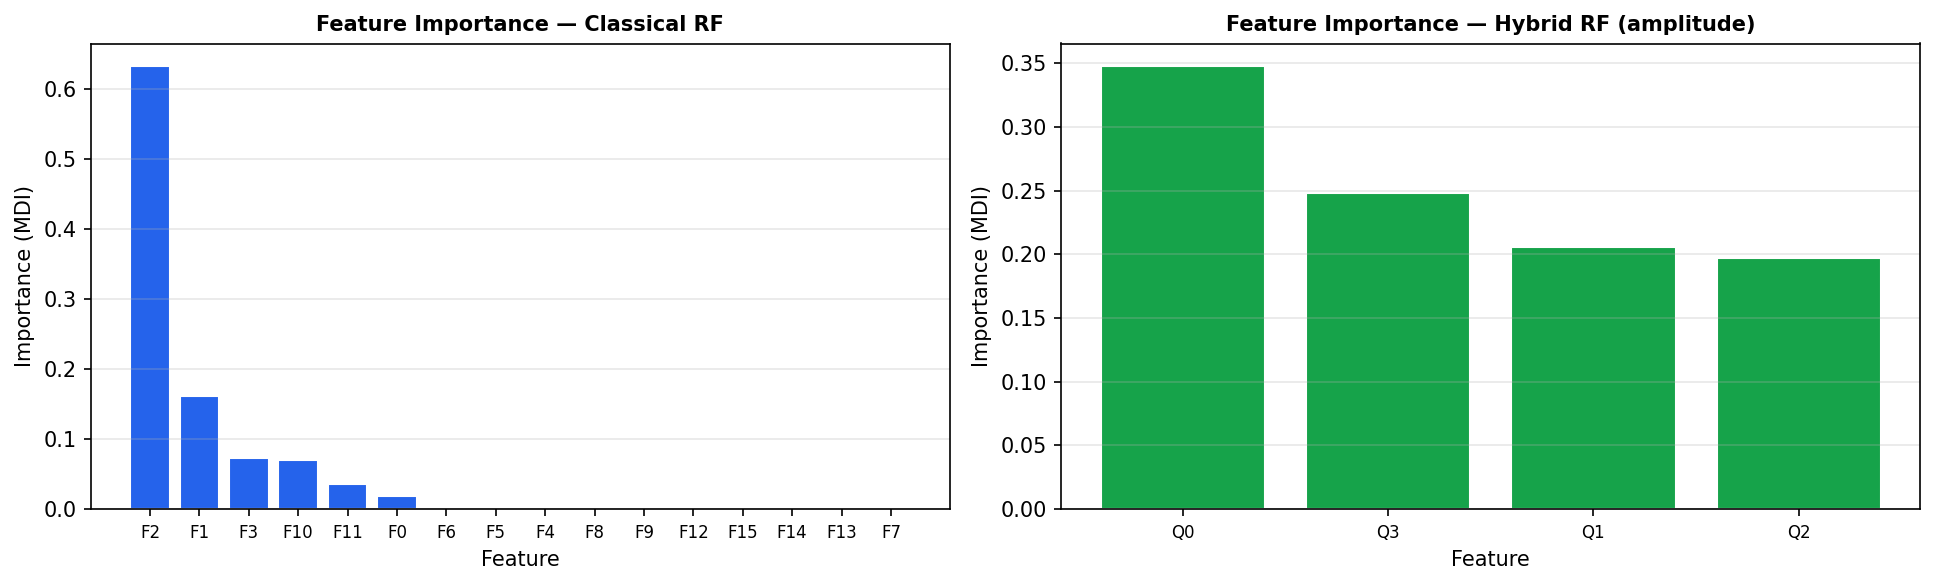

In [ ]:
# ── Cell 14 : Feature Importance ────────────────────────────────────────
# Classical RF: importance over padded {dim_amp} features (F0..F{dim_amp-1})
# Hybrid RF: importance over {n_qubits} quantum features (Q0..Q{n_qubits-1})

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=150)

for ax, (label, model, feat_names) in zip(axes, [
    ('Classical RF',
     rf_classical,
     [f'F{i}' for i in range(dim_amp)]),
    ('Hybrid RF (amplitude)',
     rf_hybrid,
     [f'Q{i}' for i in range(n_qubits)])
]):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1]
    ax.bar(range(len(imp)), imp[idx],
           color=PALETTE[label], edgecolor='white')
    ax.set_xticks(range(len(imp)))
    ax.set_xticklabels([feat_names[i] for i in idx], fontsize=8)
    ax.set_xlabel('Feature', fontsize=10)
    ax.set_ylabel('Importance (MDI)', fontsize=10)
    ax.set_title(f'Feature Importance — {label}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig5_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()